# 2. The model, on a computer

A self-contained solution to Questions 2.1 and 2.2. Run cells from top to bottom with NumPy and Matplotlib. Times are measurements on the machine used to execute this notebook and may differ elsewhere. The grid is $[0.1k^*,2k^*]$, inclusive, and the VFI stopping condition is $\|V_{n+1}-V_n\|_\infty<10^{-6}$.

Parameters: $\alpha=0.3$, $\beta=0.96$ by default. The return and steady state are
$$R(k')=\alpha(k')^{\alpha-1}+1-\delta,\qquad
k^*=\left(\frac{\alpha}{1/\beta-1+\delta}\right)^{1/(1-\alpha)}.$$

## Question 2.1(a): equations

The state space, Bellman equation, argmax policy, and sup norm convergence check have the same structure. Replace the resource constraint $c=k^\alpha-k'$ with $c=k^\alpha+(1-\delta)k-k'$ and the log utility with $u(c)=\log c$ for $\gamma=1$, or $u(c)=(c^{1-\gamma}-1)/(1-\gamma)$ otherwise. Infeasible choices $c\leq0$ receive $-\infty$. The grid endpoints use the new $k^*$ above. With $\delta<1$, the Euler return includes $1-\delta$.

The normalization of CRRA utility for $\gamma\ne1$ is immaterial for policies, but specifies the reported value function.

In [1]:
"""On-grid VFI, following the notation and loop of the in-class notebook."""
import time
from dataclasses import dataclass
import numpy as np

@dataclass(frozen=True)
class EconomicParameters:
    alpha: float = 0.3
    beta: float = 0.96
    gamma: float = 1.0
    delta: float = 1.0

@dataclass(frozen=True)
class NumericalParameters:
    nk: int = 200
    kmin_rel: float = 0.1
    kmax_rel: float = 2.0
    spacing: str = "linear"
    crit: float = 1e-6
    maxiter: int = 5000

@dataclass(frozen=True)
class Grids:
    k: np.ndarray

def util(c, par):
    if par.gamma == 1:
        return np.log(c)
    return (c ** (1 - par.gamma) - 1) / (1 - par.gamma)

def steady(alpha=.3, beta=.96, delta=1.):
    return (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))

def solve_vfi(par, mpar):
    kstar = steady(par.alpha, par.beta, par.delta)
    kmin, kmax = mpar.kmin_rel*kstar, mpar.kmax_rel*kstar
    if mpar.spacing == "linear":
        gri = Grids(k=np.linspace(kmin, kmax, mpar.nk))
    else:
        gri = Grids(k=np.exp(np.linspace(np.log(kmin), np.log(kmax), mpar.nk)))

    meshes_k, meshes_kprime = np.meshgrid(gri.k, gri.k, indexing="ij")
    C = meshes_k ** par.alpha + (1-par.delta)*meshes_k - meshes_kprime
    U = np.full(C.shape, -np.inf)
    U[C > 0] = util(C[C > 0], par)

    timer = time.perf_counter()
    v = np.zeros(mpar.nk)
    g = np.zeros(mpar.nk, dtype=int)
    distVF, iterVF = [np.inf], 0
    while distVF[-1] > mpar.crit and iterVF < mpar.maxiter:
        M = U + par.beta * v[None, :]
        vnew = np.max(M, axis=1)
        g = np.argmax(M, axis=1)
        dd = np.max(np.abs(vnew - v))
        v = vnew
        iterVF += 1
        distVF.append(dd)
    time_vfi = time.perf_counter() - timer
    if distVF[-1] > mpar.crit:
        raise RuntimeError("not converged: the iteration cap was hit")
    kprime = gri.k[g]
    consumption = gri.k**par.alpha + (1-par.delta)*gri.k - kprime
    assert np.all(consumption > 0)
    return dict(par=par,mpar=mpar,gri=gri,v=v,g=g,kprime=kprime,
                kstar=kstar,consumption=consumption,distVF=distVF,
                iterVF=iterVF,time_vfi=time_vfi)

def solve(alpha=.3,beta=.96,gamma=1.,delta=1.,N=200,crit=1e-6):
    par=EconomicParameters(alpha,beta,gamma,delta)
    mpar=NumericalParameters(nk=N,crit=crit)
    r=solve_vfi(par,mpar)
    return dict(grid=r['gri'].k,value=r['v'],idx=r['g'],policy=r['kprime'],
                consumption=r['consumption'],iterations=r['iterVF'],
                dist=r['distVF'][-1],distances=np.array(r['distVF'][1:]),
                seconds=r['time_vfi'],kstar=r['kstar'],
                boundary=(int(r['g'].min()),int(r['g'].max())),
                params=(alpha,beta,gamma,delta,N,crit),par=par,mpar=mpar,gri=r['gri'])

def euler_error(k,kp,kpp,alpha=.3,beta=.96,gamma=1.,delta=1.):
    c=k**alpha+(1-delta)*k-kp
    cp=kp**alpha+(1-delta)*kp-kpp
    R=alpha*kp**(alpha-1)+1-delta
    assert np.all(c>0) and np.all(cp>0)
    c_euler=cp/(beta*R)**(1/gamma)
    return 1-c_euler/c

def grid_errors(r):
    par=r['par']; gri=r['gri']; g=r['idx']; kprime=r['policy']
    return euler_error(gri.k,kprime,kprime[g],par.alpha,par.beta,par.gamma,par.delta)

def simulate(r,T=300,fraction=.5):
    gri=r['gri']; g=r['idx']
    i=np.argmin(abs(gri.k-fraction*r['kstar']))
    path=np.empty(T+1)
    for t in range(T+1):
        path[t]=gri.k[i]
        i=g[i]
    return path

import matplotlib.pyplot as plt
print('Functions loaded: steady, solve, euler_error, grid_errors, simulate')

Functions loaded: steady, solve, euler_error, grid_errors, simulate


Each solve prints its parameters, iteration count, final distance, and boundary check. The boundary check reports the smallest and largest chosen grid *indices*, then flags whether either endpoint is chosen.

In [2]:
def run(alpha=.3,beta=.96,gamma=1.,delta=1.,N=200,crit=1e-6):
    r=solve(alpha,beta,gamma,delta,N,crit)
    print(f"Value function iteration with parameters alpha = {alpha}, beta = {beta}, gamma = {gamma}, delta = {delta}, N = {N}, crit = {crit}")
    lo,hi=r['boundary']
    print(f"iterations = {r['iterations']}, final distance = {r['dist']:.9g}, boundary check: chosen indices [{lo}, {hi}], endpoints chosen = {lo==0 or hi==N-1}")
    return r

base=run()

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1e-06
iterations = 337, final distance = 9.79225028e-07, boundary check: chosen indices [42, 118], endpoints chosen = False


## Question 2.1(b): closed form check

For $\gamma=\delta=1$, $k'(k)=\alpha\beta k^\alpha$. Write $V(k)=A+B\log k$, where
$$B=\frac{\alpha}{1-\alpha\beta},\qquad
A=\frac{\log(1-\alpha\beta)+\beta B\log(\alpha\beta)}{1-\beta}.$$
The max norm comparison below uses the *continuous* closed form evaluated at grid states, so the grid approximation generates a small nonzero error.

In [3]:
alpha,beta=.3,.96
B=alpha/(1-alpha*beta)
A=(np.log(1-alpha*beta)+beta*B*np.log(alpha*beta))/(1-beta)
k=base['grid']; exact_policy=alpha*beta*k**alpha
print(f"largest policy error = {np.max(np.abs(base['policy']-exact_policy)):.9g}")
print(f"largest value error = {np.max(np.abs(base['value']-(A+B*np.log(k)))):.9g}")

largest policy error = 0.000939173609
largest value error = 2.40723738e-05


## Question 2.1(c,d): Euler equation error

The Euler equation is $c_t^{-\gamma}=\beta c_{t+1}^{-\gamma}R(k_{t+1})$. The consumption implied by tomorrow's consumption is $\widehat c_t=c_{t+1}/[\beta R(k_{t+1})]^{1/\gamma}$. Hence $e_t=1-\widehat c_t/c_t$. Its magnitude is the consumption deviation as a fraction of current consumption. For an on-grid policy, tomorrow's policy is retrieved from the chosen grid index; for the analytic check, both future choices use the continuous closed form.

In [4]:
k=base['grid']; kp=alpha*beta*k**alpha; kpp=alpha*beta*kp**alpha
analytic_error=euler_error(k,kp,kpp)
print(f"closed form Euler error, max absolute = {np.max(np.abs(analytic_error)):.3g}")
e=grid_errors(base); j=np.argmax(np.abs(e))
print(f"For the on-grid policy, max |e_i| = {abs(e[j]):.8f} at k_i = {k[j]:.8f}; this corresponds to {100*abs(e[j]):.4f}% of consumption.")

closed form Euler error, max absolute = 6.66e-16
For the on-grid policy, max |e_i| = 0.01169673 at k_i = 0.01850576; this corresponds to 1.1697% of consumption.


## Question 2.1(e,f): CRRA and partial depreciation

Set $\gamma=2$, $\delta=0.1$. The Euler calculation evaluates tomorrow's policy *on the grid*. The 45 degree crossing is an interval of fixed grid states because an on-grid policy can have several adjacent states with $k'=k$.

In [5]:
r200=run(gamma=2,delta=.1)
e200=grid_errors(r200); j=np.argmax(np.abs(e200)); g=r200['grid']
fixed=g[r200['idx']==np.arange(len(g))]
print(f"max |e_i| = {abs(e200[j]):.8f} at k_i = {g[j]:.8f}, or {100*abs(e200[j]):.4f}% of consumption.")
print(f"mean log10 |e_i| = {np.mean(np.log10(np.abs(e200))):.8f}")
print(f"45 degree fixed-grid interval = [{fixed.min():.8f}, {fixed.max():.8f}]; k* = {r200['kstar']:.8f}")
print(f"The maximum Euler error is at grid index {j} of {len(g)-1}, near the lower edge of the grid.")

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2, delta = 0.1, N = 200, crit = 1e-06
iterations = 226, final distance = 9.80425056e-07, boundary check: chosen indices [6, 187], endpoints chosen = False
max |e_i| = 0.04562596 at k_i = 0.29208221, or 4.5626% of consumption.
mean log10 |e_i| = -2.16005900
45 degree fixed-grid interval = [2.88559615, 2.94137065]; k* = 2.92082215
The maximum Euler error is at grid index 0 of 199, near the lower edge of the grid.


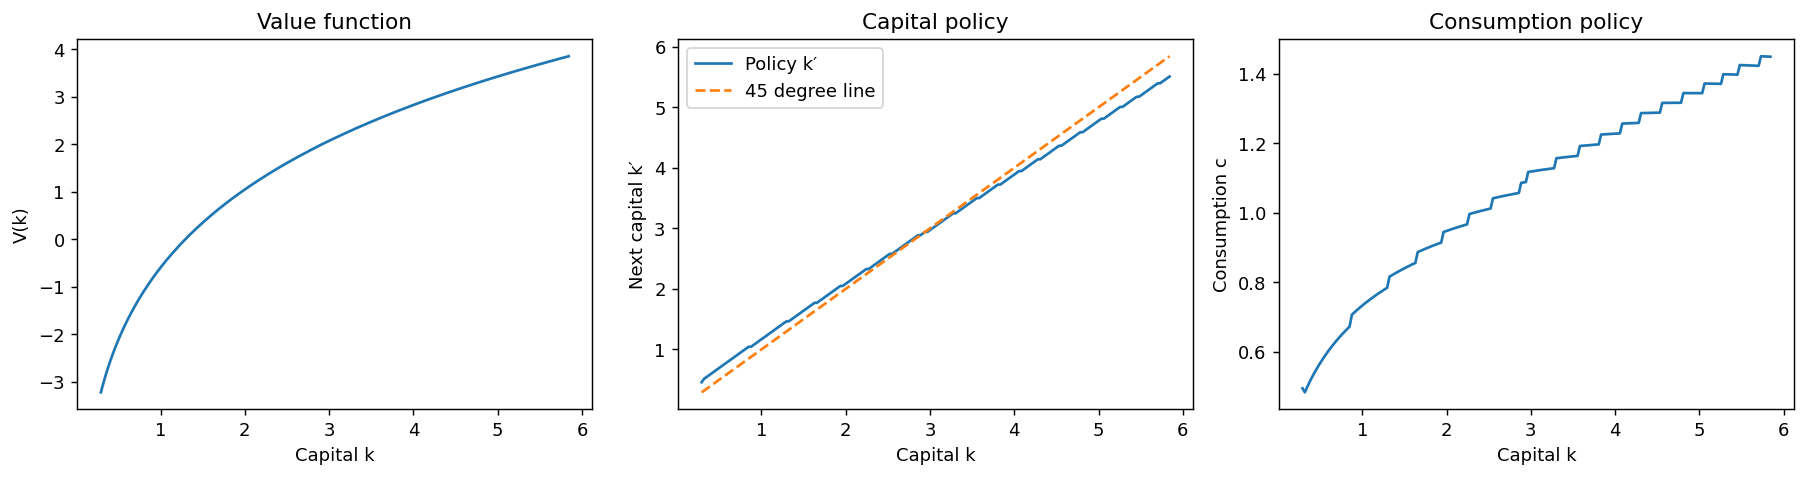

In [6]:
fig,axs=plt.subplots(1,3,figsize=(14,3.8))
axs[0].plot(g,r200['value']); axs[0].set(title='Value function',xlabel='Capital k',ylabel='V(k)')
axs[1].plot(g,r200['policy'],label="Policy k′"); axs[1].plot(g,g,'--',label='45 degree line'); axs[1].legend(); axs[1].set(title='Capital policy',xlabel='Capital k',ylabel="Next capital k′")
axs[2].plot(g,r200['consumption']); axs[2].set(title='Consumption policy',xlabel='Capital k',ylabel='Consumption c')
fig.tight_layout(); display(fig)

The crossing interval contains $k^*$. Errors are largest near low capital because output, marginal returns, and consumption change most rapidly there; snapping desired savings to the nearest grid point has the largest effect on the Euler condition at that edge.

## Question 2.2(a): 300 period simulation

Start at the grid point closest to $0.5k^*$ and repeatedly use the integer policy index $i_{t+1}=g_{i_t}$.

The path settles at 2.88559615, 0.03522600 away from k* = 2.92082215.


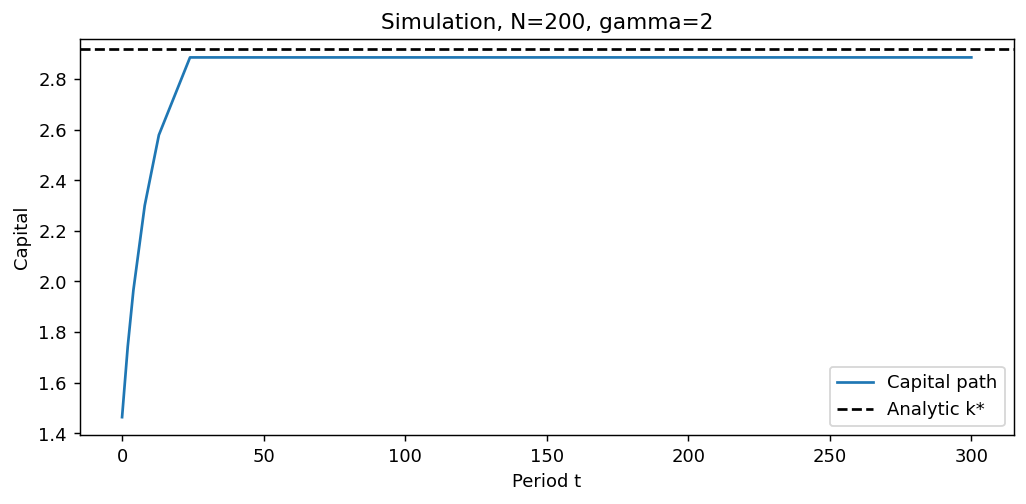

In [7]:
path200=simulate(r200,T=300)
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(np.arange(301),path200,label='Capital path')
ax.axhline(r200['kstar'],ls='--',color='black',label='Analytic k*')
ax.set(xlabel='Period t',ylabel='Capital',title='Simulation, N=200, gamma=2'); ax.legend(); fig.tight_layout(); display(fig)
print(f"The path settles at {path200[-1]:.8f}, {abs(path200[-1]-r200['kstar']):.8f} away from k* = {r200['kstar']:.8f}.")

## Question 2.2(b,c): grid cost and extrapolation

Elapsed time below measures only the VFI loop and differs across machines. The policy indices and Euler errors are evaluated after solving. The last column is the fixed grid state reached by the simulation from $0.5k^*$.

In [8]:
runs={50:run(gamma=2,delta=.1,N=50),200:r200,800:run(gamma=2,delta=.1,N=800)}
print('\nN       spacing    iterations   VFI seconds      max |e|       settling k')
for n,r in runs.items():
    er=grid_errors(r)
    print(f"{n:<7} {r['grid'][1]-r['grid'][0]:.8f} {r['iterations']:>8} {r['seconds']:>14.6f} {np.max(np.abs(er)):>13.8f} {simulate(r)[-1]:>15.8f}")

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2, delta = 0.1, N = 50, crit = 1e-06
iterations = 230, final distance = 9.66680964e-07, boundary check: chosen indices [2, 46], endpoints chosen = False
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2, delta = 0.1, N = 800, crit = 1e-06
iterations = 226, final distance = 9.62169148e-07, boundary check: chosen indices [26, 751], endpoints chosen = False

N       spacing    iterations   VFI seconds      max |e|       settling k
50      0.11325637      230       0.002804    0.16531911      2.78372233
200     0.02788725      226       0.010667    0.04562596      2.88559615
800     0.00694563      226       0.120733    0.01110803      2.91058648


At fixed convergence tolerance, iteration count is roughly constant as $N$ grows. Grid spacing scales as $N^{-1}$, and the measured maximum Euler error is approximately first order in spacing (about $0.1653$, $0.04563$, $0.01111$ for $N=50,200,800$). Each Bellman iteration compares $N^2$ state-choice pairs, giving theoretical time order $O(N^2)$ and memory order $O(N^2)$. For these small grids, setup overhead and caching make actual timing ratios less stable than the asymptotic prediction. For a machine-specific estimate use the $N=800$ measurement:

In [9]:
e800=np.max(np.abs(grid_errors(runs[800])))
N_est=int(np.ceil(800*e800/1e-4))
secs_est=runs[800]['seconds']*(N_est/800)**2
print(f"N ≈ 800 × ({e800:.8f} / 1e-4) = {N_est:,}; VFI time ≈ {runs[800]['seconds']:.4f} × ({N_est}/800)^2 = {secs_est:.0f} s = {secs_est/60:.1f} min.")
print(f"One float64 N×N array at that grid size requires about {8*N_est*N_est/1e9:.1f} GB; the current implementation uses multiple such arrays, so this extrapolated run requires a different memory-efficient algorithm.")

N ≈ 800 × (0.01110803 / 1e-4) = 88,865; VFI time ≈ 0.1207 × (88865/800)^2 = 1490 s = 24.8 min.
One float64 N×N array at that grid size requires about 63.2 GB; the current implementation uses multiple such arrays, so this extrapolated run requires a different memory-efficient algorithm.


## Question 2.2(d,e): risk aversion

The same steady state applies to $\gamma=1,2,5$. Report the first period within $5\%$ of $k^*$ and the savings rate at the actual initial *grid point*, $(k_1-(1-\delta)k_0)/k_0^\alpha$.

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1, delta = 0.1, N = 800, crit = 1e-06
iterations = 156, final distance = 9.73483019e-07, boundary check: chosen indices [39, 731], endpoints chosen = False
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5, delta = 0.1, N = 800, crit = 1e-06
iterations = 247, final distance = 9.65718651e-07, boundary check: chosen indices [13, 769], endpoints chosen = False

gamma    1/gamma     first t within 5%       savings rate at k0
    1      1.0000                   15                 0.316311
    2      0.5000                   22                 0.254296
    5      0.2000                   37                 0.198482


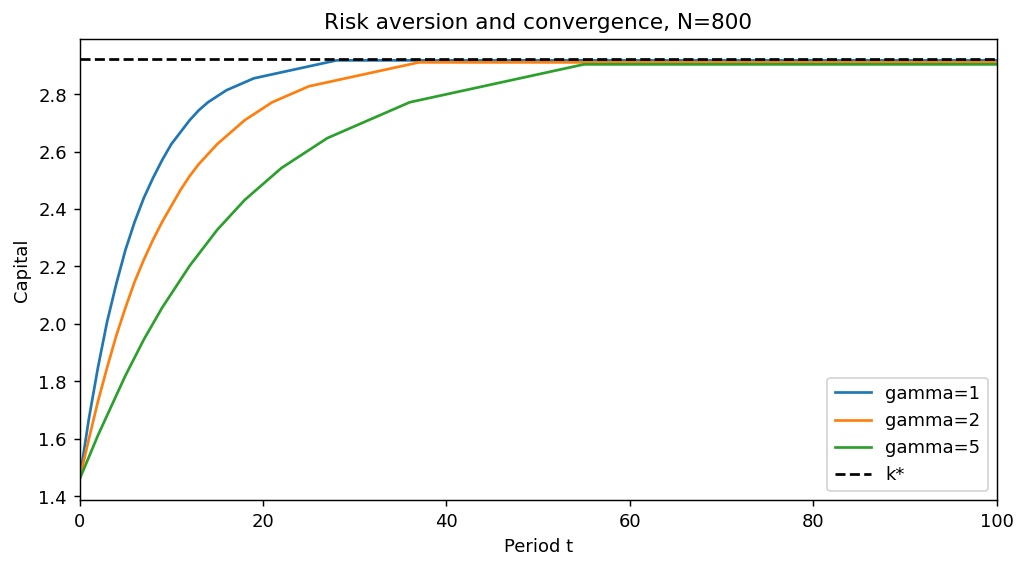

In [10]:
risk={1:run(gamma=1,delta=.1,N=800),2:runs[800],5:run(gamma=5,delta=.1,N=800)}
paths={gamma:simulate(r,T=300) for gamma,r in risk.items()}
print('\ngamma    1/gamma     first t within 5%       savings rate at k0')
for gamma,r in risk.items():
    path=paths[gamma]; t=np.flatnonzero(abs(path-r['kstar'])<=.05*r['kstar'])[0]
    savings=(path[1]-.9*path[0])/path[0]**.3
    print(f"{gamma:>5} {1/gamma:>11.4f} {t:>20} {savings:>24.6f}")
fig,ax=plt.subplots(figsize=(8,4.5))
for gamma,path in paths.items(): ax.plot(np.arange(len(path)),path,label=f'gamma={gamma}')
ax.axhline(risk[1]['kstar'],ls='--',color='black',label='k*')
ax.set(xlim=(0,100),xlabel='Period t',ylabel='Capital',title='Risk aversion and convergence, N=800'); ax.legend(); fig.tight_layout(); display(fig)

The $\gamma=1$ household reaches the five-percent band fastest. Its intertemporal elasticity of substitution $1/\gamma=1$ exceeds $1/2$ and $1/5$ for the others, so its consumption responds more to the incentive to postpone consumption when capital is scarce. The initial saving rates printed above decline as $\gamma$ rises, and the corresponding paths converge more slowly. The precise stopping grid point varies with discretization.